# Definitions

Replicating the simplest example they present in the Swap-Test Classifier paper.

In [17]:
### Import Modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import SdgGate, ZGate, HGate
from qiskit.circuit.library import UnitaryGate, Initialize
from qiskit.circuit import Gate
from qiskit.visualization import circuit_drawer
import numpy as np

# Preparation State

## Initialization

In [18]:
qr_a = QuantumRegister(1, 'a') # Ancilla
qr_d = QuantumRegister(1, 'd') # Data
qr_l = QuantumRegister(1, 'l') # Label
qr_m = QuantumRegister(1, 'm') # Index
qr_in = QuantumRegister(1, 'in') # Test

qc = QuantumCircuit(qr_a, qr_d, qr_l, qr_m, qr_in)

## State Preparation

In [19]:
### Superposition of training data
qc.h(qr_m)

### Encode training data
qc.h(qr_d) # Hadamard
qc.rz(-np.pi, qr_d) # Rz†(π)
qc.s(qr_d) # S gate
qc.append(ZGate().control(), [qr_m, qr_d])  # Controlled-Z on index

### Test data
in_angle = np.pi/2
qc.rx(in_angle, qr_in) # Choosing 90º (peak expectation value, y=0)

### Label
qc.cx(qr_m, qr_l) # Controlled-X on index

# Classifier Circuit

## Swap-Test Circuit

In [20]:
### Hadamard - Swap - Hadamard ###

# Hadamard
qc.h(qr_a) 
# Controlled-SWAP gate, also known as the Fredkin gate.
qc.cswap(qr_a, qr_d, qr_in)
# Hadamard
qc.h(qr_a) 

## Measurements

In [21]:
import matplotlib.pyplot as plt

###################################### Two single-qubit measurements ##################################

cr_a = ClassicalRegister(1, 'cr_a') # ancilla qubit
cr_l = ClassicalRegister(1, 'cr_l') # label qubit
qc.add_register(cr_a)
qc.add_register(cr_l)
# Leftmost bit corresponds to the last classical register measured
qc.measure(qr_a, cr_a)
qc.measure(qr_l, cr_l)

######################################### Simulate (Qiskit 2.0.1) #####################################

# Simulate
from qiskit_aer import AerSimulator
simulator = AerSimulator()
print(simulator.configuration())

nr_shots = 10000
job = simulator.run(qc, shots=nr_shots)
result = job.result()

# Results
counts = result.get_counts()
print("Counts:", counts)

Counts: {'0 0': 4967, '1 0': 2578, '1 1': 2455}


In [22]:
def f_expectation_value(counts):
    """
    Calculate the two-qubit expectation value <σ_z(a),σ_z(l)>.
    From a dictionary to a string.
    """
    shots = sum(counts.values())
    return (
        counts.get('0 0', 0)
        - counts.get('0 1', 0)
        - counts.get('1 0', 0)
        + counts.get('1 1', 0)
    ) / float(shots)

expectation_value = f_expectation_value(counts)

def predicted_label(expectation_value):
    return (0 if expectation_value > 0 else 1)

print(f"Counts: {counts}, Expectation Value: {expectation_value} -> Predicted Label: {predicted_label(expectation_value)}")

Counts: {'0 0': 4967, '1 0': 2578, '1 1': 2455}, Expectation Value: 0.4844 -> Predicted Label: 0


# Draw and Visualize

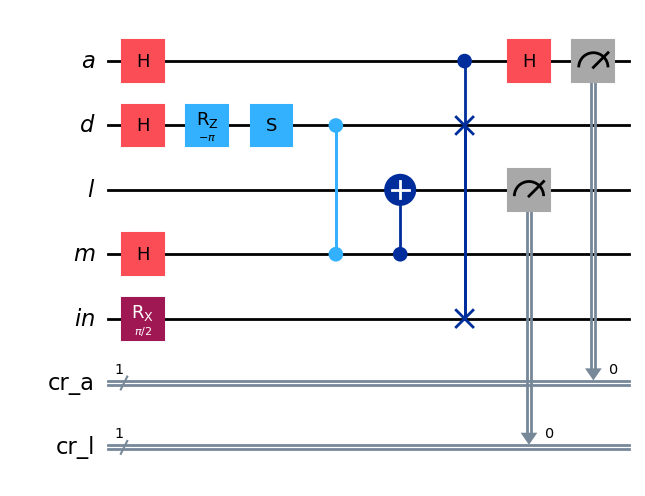

In [23]:
circuit_drawer(qc, output='mpl', filename='network_circuit_papers_example.png')
qc.draw(output='mpl', filename='network_circuit_papers_example.png')

# Plot Label vs Angle

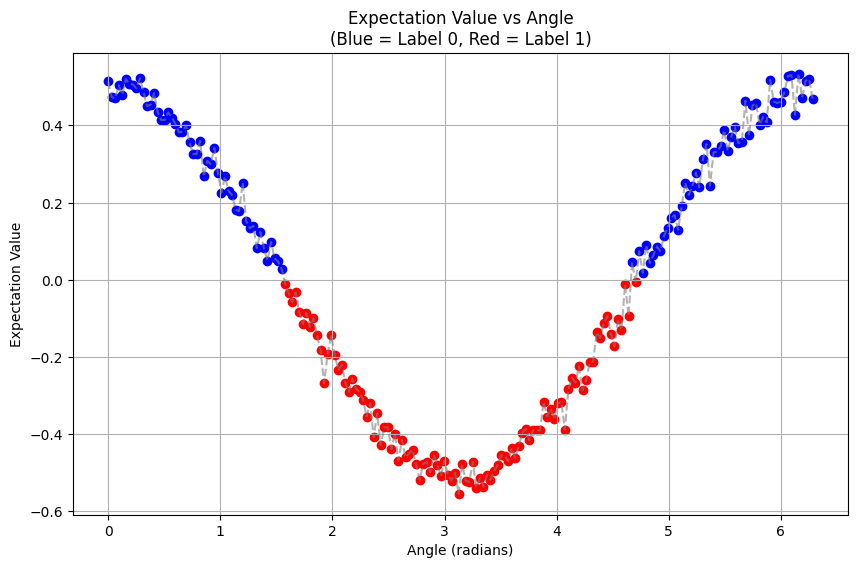

In [24]:
def simulate_for_angle(angle, data = 'paper', shots=10000):
    qr_a = QuantumRegister(1, 'a')
    qr_d = QuantumRegister(1, 'd')
    qr_l = QuantumRegister(1, 'l')
    qr_m = QuantumRegister(1, 'm')
    qr_in = QuantumRegister(1, 'in')
    cr_a = ClassicalRegister(1, 'cr_a')
    cr_l = ClassicalRegister(1, 'cr_l')
    qc = QuantumCircuit(qr_a, qr_d, qr_l, qr_m, qr_in, cr_a, cr_l)

    qc.h(qr_m)
    ### Alternative:
    # w_v = [
    #     np.sqrt(1 / 6), # |0>
    #     np.sqrt(5 / 6) # |1>
    # ]
    # w_v /= np.linalg.norm(w_v)
    # w_v_gate = Initialize(w_v)
    # qc.append(w_v_gate, qr_m)

    # Embedding
    if data == 'paper':
        qc.h(qr_d)
        qc.rz(-np.pi, qr_d)
        qc.s(qr_d)
        qc.append(ZGate().control(), [qr_m, qr_d])   
    elif data == '0or1':
        qc.cx(qr_m, qr_d)
    qc.rx(angle, qr_in) # Angle varies
    qc.cx(qr_m, qr_l) # Label
    # Classifier
    qc.h(qr_a)
    qc.cswap(qr_a, qr_d, qr_in)
    qc.h(qr_a)
    qc.measure(qr_a, cr_a)
    qc.measure(qr_l, cr_l)

    simulator = AerSimulator()
    job = simulator.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    def f_expectation_value(counts):
        shots = sum(counts.values())
        return (
            counts.get('0 0', 0) - counts.get('0 1', 0)
            - counts.get('1 0', 0) + counts.get('1 1', 0)
        ) / float(shots)

    exp_val = f_expectation_value(counts)
    pred_label = 0 if exp_val > 0 else 1
    return angle, exp_val, pred_label

angles = np.linspace(0, 2 * np.pi, 200)
results = [simulate_for_angle(a, data = '0or1', shots=1000) for a in angles]

x_vals = [r[0] for r in results]
y_vals = [r[1] for r in results]
colors = ['blue' if r[2] == 0 else 'red' for r in results]

plt.figure(figsize=(10, 6))
for x, y, c in zip(x_vals, y_vals, colors):
    plt.scatter(x, y, color=c)
plt.plot(x_vals, y_vals, linestyle='dashed', alpha=0.6, color='gray')
plt.xlabel("Angle (radians)")
plt.ylabel("Expectation Value")
plt.title("Expectation Value vs Angle\n(Blue = Label 0, Red = Label 1)")
plt.grid(True)
plt.show()